# Sparse LSEG event strategy: retrospective falsification

**Question.** Does converting Gemma headline sentiment from a dense daily
average into a sparse event-selection and position-sizing signal improve the
expanded 44-company LSEG strategy result?

**Frozen before opening returns.** The new primary family contains exactly
two signals—(1) the strongest novel material event and (2) the same event
attenuated by an unvalidated headline-only proxy for cash-flow distance—each
carried for 1, 3, or 5 exchange sessions. The novelty window is 30 days with
Jaccard threshold 0.80. All arms use the first exchange open at least 15
minutes after publication, raw next-open returns, cross-sectional rank weights,
gross exposure one, at least 10 active names, 10 bps per side, explicit
inactive-day closure and final liquidation, HAC(5) IC inference, BH over all
six arms, and a 1,999-replication five-session circular block bootstrap.

**Success gate.** An arm must survive BH at q=0.05, have positive net Sharpe,
break even at or above 10 bps per side, have a positive bootstrap lower bound
for mean net return, and have positive gross mean in both temporal halves.

**Status.** This is retrospective discovery/falsification on an already-open
eight-month return window. It is not a pristine holdout, cannot promote an
alpha claim, does not replace Gate F1, and is never pooled with FNSPID. The
event taxonomy, novelty rule, and cash-flow-distance proxy remain unvalidated.

In [1]:
from __future__ import annotations

import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    message="This pattern is interpreted as a regular expression.*",
    category=UserWarning,
)

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.lseg_expanded import (  # noqa: E402
    INFORMATION_BUFFER_MINUTES,
    load_price_exports,
    load_success_scores,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    apply_house_style,
)
from final_experiments.lib.sparse_events import (  # noqa: E402
    BOOTSTRAP_BLOCK_SESSIONS,
    BOOTSTRAP_REPLICATIONS,
    COST_BPS_PER_SIDE,
    HOLDING_HORIZONS,
    MATERIAL_EVENT_TYPES,
    MIN_PORTFOLIO_NAMES,
    NOVELTY_JACCARD_THRESHOLD,
    NOVELTY_WINDOW_DAYS,
    SEED,
    SPARSE_PRIMARY_FAMILY,
    build_sparse_state_panels,
    evaluate_sparse_arms,
    prepare_sparse_event_candidates,
    select_strongest_sparse_events,
)

COLLECTION_ROOT = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived"
GEMMA_SCORES = (
    COLLECTION_ROOT
    / "headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv"
)
SECTOR33_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
ADD11_PRICES = REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv"
REFERENCE_RESULTS = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness/primary_18_arm_results.csv"
)
OUTPUT = REPO_ROOT / "final_experiments/outputs/14_lseg_sparse_event_strategy"
OUTPUT.mkdir(parents=True, exist_ok=True)
apply_house_style()

print("status: retrospective discovery/falsification; not a holdout")
print("family:", SPARSE_PRIMARY_FAMILY)
print("signals: strongest novel material event; same event divided by (1 + proxy distance)")
print("horizons:", HOLDING_HORIZONS)
print(f"timing: first exchange open >= timestamp + {INFORMATION_BUFFER_MINUTES} minutes")
print(f"cost: {COST_BPS_PER_SIDE:.1f} bps/side; minimum active names: {MIN_PORTFOLIO_NAMES}")

status: retrospective discovery/falsification; not a holdout
family: two predeclared sparse signals x three state horizons; daily cross-sectional IC, BH-FDR q=0.05
signals: strongest novel material event; same event divided by (1 + proxy distance)
horizons: (1, 3, 5)
timing: first exchange open >= timestamp + 15 minutes
cost: 10.0 bps/side; minimum active names: 10


## 1. Inputs and label-only eligibility audit

Headline text is loaded only into memory for local regex and novelty feature
construction. It is removed by the helper before any table is written. The
score artifact remains append-only, so only `status == "success"` enters.

In [2]:
gemma, score_audit = load_success_scores(
    GEMMA_SCORES,
    scorer="gemma4_26b",
    include_headline=True,
)
prices = load_price_exports(SECTOR33_PRICES, ADD11_PRICES)

input_audit = pd.DataFrame(
    [
        {
            **{key: value for key, value in score_audit.items() if key != "status_counts"},
            **{
                f"status_{key}": value
                for key, value in score_audit["status_counts"].items()
            },
        }
    ]
)
input_audit.to_csv(OUTPUT / "input_score_audit.csv", index=False)
display(input_audit)

,scorer,rows_including_historical_attempts,unique_successes,duplicate_successes,invalid_success_probabilities,reported_cost_usd_sum,output_sha256,status_success,status_api_error,status_invalid_output,status_malformed_response
0,gemma4_26b,889103,888155,0,0,33.615345,afb2d9c3029c4fba4fce3600218233a02d14051788f873...,888155,919,27,2


In [3]:
mapped, funnel = prepare_sparse_event_candidates(gemma, prices)
del gemma

event_type_counts = (
    mapped.groupby("event_type", observed=True)
    .agg(
        mapped_headlines=("headline_sha256", "nunique"),
        symbols=("symbol", "nunique"),
        entry_sessions=("entry_session", "nunique"),
    )
    .reindex(MATERIAL_EVENT_TYPES)
    .fillna(0)
    .reset_index()
)
distance_counts = (
    mapped.assign(
        proxy_distance=mapped["proxy_cash_flow_distance"].astype("Int64")
    )
    .groupby("proxy_distance", dropna=False, observed=True)
    .agg(mapped_headlines=("headline_sha256", "nunique"))
    .reset_index()
)
funnel.to_csv(OUTPUT / "eligibility_funnel.csv", index=False)
event_type_counts.to_csv(OUTPUT / "event_type_counts.csv", index=False)
distance_counts.to_csv(OUTPUT / "distance_proxy_counts.csv", index=False)
display(funnel.style.format({"share_of_successes": "{:.2%}"}))
display(event_type_counts)
display(distance_counts)

,stage,headlines,share_of_successes
0,successful_unique_headlines,888155,100.00%
1,explicit_target,745163,83.90%
2,single_company,723658,81.48%
3,exclude_market_price_technical,582488,65.58%
4,material_event_type,191875,21.60%
5,novel_material_event,172198,19.39%
6,novel_with_distance_proxy,61988,6.98%
7,mapped_to_eligible_open,172198,19.39%


,event_type,mapped_headlines,symbols,entry_sessions
0,earnings_guidance,48902,44,167
1,mna_strategy,26425,44,167
2,legal_regulatory,10151,44,167
3,product_technology,55582,44,167
4,management_governance,29109,44,167
5,labor_esg,2029,44,167


,proxy_distance,mapped_headlines
0,0,23300
1,1,19340
2,2,7468
3,3,11880
4,<NA>,110210


findfont: Failed to find font weight medium, now using 400.


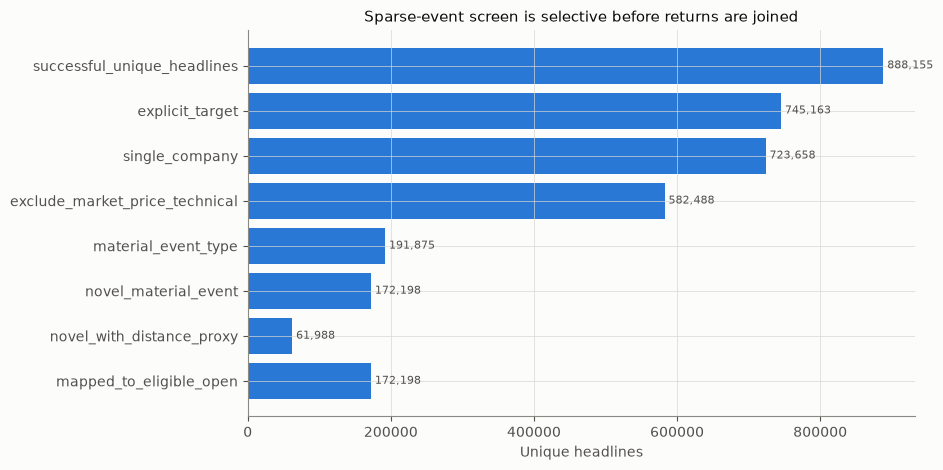

In [4]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
plot_funnel = funnel.iloc[::-1]
ax.barh(plot_funnel["stage"], plot_funnel["headlines"], color=CATEGORICAL[0])
for y, value in enumerate(plot_funnel["headlines"]):
    ax.text(value, y, f" {int(value):,}", va="center", fontsize=8, color=INK["secondary"])
ax.set_xlabel("Unique headlines")
ax.set_title("Sparse-event screen is selective before returns are joined")
fig.tight_layout()
fig.savefig(OUTPUT / "eligibility_funnel.png", dpi=160, bbox_inches="tight")
plt.show()

The attrition funnel is a design diagnostic, not a performance result. The
distance arm remains missing when no frozen phrase matches; unknown cases are
not coerced toward either realised or speculative cash flow.

## 2. Select one event and construct fixed-horizon state panels

Selection uses the largest absolute Gemma score within company and eligible
entry open. Equal-magnitude opposite-sign ties are omitted. The distance arm
uses the same selected event, so the comparison changes only sizing and
coverage—not which known-distance event wins after seeing its return.

In [5]:
selected = select_strongest_sparse_events(mapped)
selection_audit = pd.DataFrame(
    [
        {
            "mapped_novel_headlines": int(mapped["headline_sha256"].nunique()),
            "selected_company_entry_events": int(len(selected)),
            "selected_symbols": int(selected["symbol"].nunique()),
            "selected_entry_sessions": int(selected["entry_session"].nunique()),
            "selected_with_distance_proxy": int(selected["distance_signal"].notna().sum()),
        }
    ]
)
selection_audit.to_csv(OUTPUT / "selection_audit.csv", index=False)
display(selection_audit)

panels = build_sparse_state_panels(selected, prices)
panel_coverage = pd.DataFrame(
    [
        {
            "signal": signal,
            "state_horizon_sessions": horizon,
            "active_firm_sessions": int(panel[signal].notna().sum()),
            "active_sessions": int(
                panel.loc[panel[signal].notna(), "session_date"].nunique()
            ),
            "mean_active_names": float(
                panel.loc[panel[signal].notna()]
                .groupby("session_date")
                .size()
                .mean()
            ),
        }
        for horizon, panel in panels.items()
        for signal in ("material_signal", "distance_signal")
    ]
)
panel_coverage.to_csv(OUTPUT / "panel_coverage.csv", index=False)
display(panel_coverage.style.format(precision=2))

,mapped_novel_headlines,selected_company_entry_events,selected_symbols,selected_entry_sessions,selected_with_distance_proxy
0,172198,6127,44,167,2570


,signal,state_horizon_sessions,active_firm_sessions,active_sessions,mean_active_names
0,material_signal,1,6127,167,36.69
1,distance_signal,1,2570,167,15.39
2,material_signal,3,7330,169,43.37
3,distance_signal,3,3083,169,18.24
4,material_signal,5,7489,171,43.80
5,distance_signal,5,3152,171,18.43


## 3. Frozen six-arm return evaluation

BH is applied once across the six new IC tests. Notebook 13's Gemma
`strongest_event` is a historical reference only and is not smuggled into the
new multiplicity family.

In [6]:
results, daily_outputs = evaluate_sparse_arms(
    panels,
    cost_bps_per_side=COST_BPS_PER_SIDE,
    bootstrap_replications=BOOTSTRAP_REPLICATIONS,
    seed=SEED,
)
results.to_csv(OUTPUT / "primary_6_arm_results.csv", index=False)
for (signal, horizon), daily in daily_outputs.items():
    daily.to_csv(OUTPUT / f"daily_{signal}_h{horizon}.csv", index=False)

show = [
    "arm",
    "active_firm_sessions",
    "active_sessions",
    "mean_active_names",
    "ic",
    "ic_p",
    "ic_p_bh",
    "bh_reject_ic_q05",
    "sharpe_gross",
    "sharpe_net",
    "breakeven_bps_per_side",
    "bootstrap_net_ci_low",
    "bootstrap_net_ci_high",
    "temporal_sign_stable_positive",
    "economically_viable",
]
display(results[show].sort_values("ic_p").style.format(precision=4))

,arm,active_firm_sessions,active_sessions,mean_active_names,ic,ic_p,ic_p_bh,bh_reject_ic_q05,sharpe_gross,sharpe_net,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high,temporal_sign_stable_positive,economically_viable
4,material_signal_h5,7459,170,43.8765,0.0069,0.5955,0.8185,False,0.6627,-2.8202,1.9038,-0.0012,-0.0001,True,False
5,distance_signal_h5,3139,170,18.4647,0.0082,0.6706,0.8185,False,-0.1553,-4.1330,-0.3900,-0.0020,-0.0007,False,False
2,material_signal_h3,7330,169,43.3728,0.0052,0.6788,0.8185,False,0.5794,-2.9832,1.6284,-0.0012,-0.0002,True,False
1,distance_signal_h1,2570,167,15.3892,0.0088,0.6796,0.8185,False,0.2135,-3.7084,0.5461,-0.0022,-0.0006,False,False
3,distance_signal_h3,3083,169,18.2426,0.0077,0.6888,0.8185,False,-0.2822,-4.2628,-0.7083,-0.0021,-0.0007,False,False
0,material_signal_h1,6127,167,36.6886,0.0032,0.8185,0.8185,False,0.3418,-3.7441,0.8371,-0.0016,-0.0004,False,False


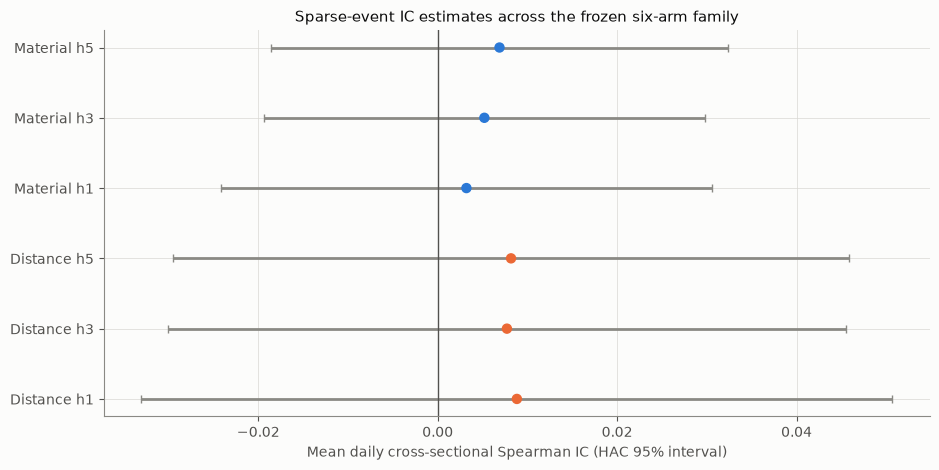

In [7]:
plot_results = results.sort_values(["signal", "state_horizon_sessions"]).copy()
labels = [
    f"{'Material' if signal == 'material_signal' else 'Distance'} h{horizon}"
    for signal, horizon in zip(
        plot_results["signal"],
        plot_results["state_horizon_sessions"],
        strict=True,
    )
]
colours = [
    CATEGORICAL[0] if signal == "material_signal" else CATEGORICAL[1]
    for signal in plot_results["signal"]
]
fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(plot_results))
ax.errorbar(
    plot_results["ic"],
    y,
    xerr=1.96 * plot_results["ic_se"],
    fmt="none",
    ecolor=INK["muted"],
    capsize=3,
)
ax.scatter(plot_results["ic"], y, c=colours, s=42, zorder=3)
ax.axvline(0, color=INK["reference"], linewidth=1)
ax.set_yticks(y, labels)
ax.set_xlabel("Mean daily cross-sectional Spearman IC (HAC 95% interval)")
ax.set_title("Sparse-event IC estimates across the frozen six-arm family")
fig.tight_layout()
fig.savefig(OUTPUT / "six_arm_ic_intervals.png", dpi=160, bbox_inches="tight")
plt.show()

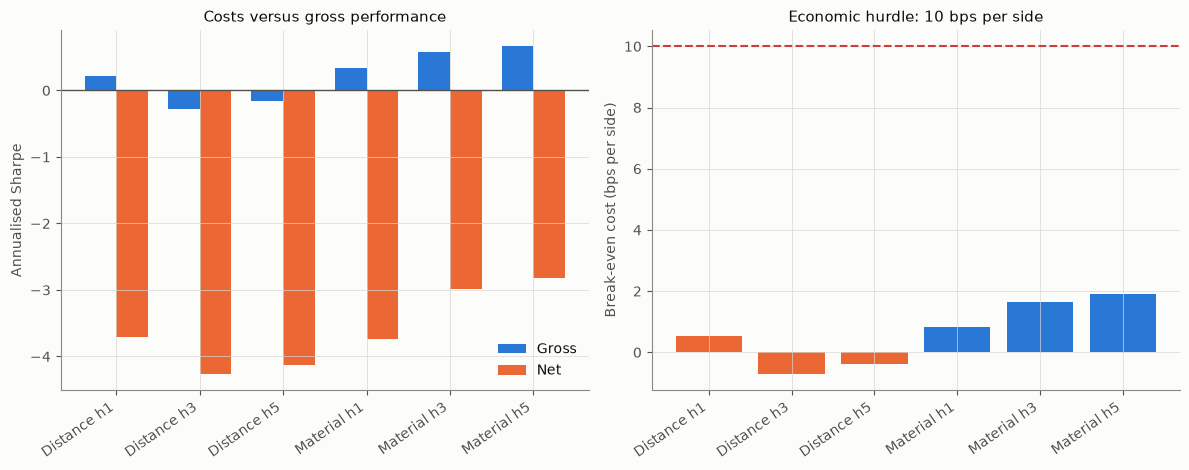

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
x = np.arange(len(plot_results))
axes[0].bar(x - 0.19, plot_results["sharpe_gross"], width=0.38, color=CATEGORICAL[0], label="Gross")
axes[0].bar(x + 0.19, plot_results["sharpe_net"], width=0.38, color=CATEGORICAL[1], label="Net")
axes[0].axhline(0, color=INK["reference"], linewidth=1)
axes[0].set_xticks(x, labels, rotation=35, ha="right")
axes[0].set_ylabel("Annualised Sharpe")
axes[0].set_title("Costs versus gross performance")
axes[0].legend()

axes[1].bar(x, plot_results["breakeven_bps_per_side"], color=colours)
axes[1].axhline(COST_BPS_PER_SIDE, color=STATUS["critical"], linestyle="--", linewidth=1.5)
axes[1].set_xticks(x, labels, rotation=35, ha="right")
axes[1].set_ylabel("Break-even cost (bps per side)")
axes[1].set_title("Economic hurdle: 10 bps per side")
fig.tight_layout()
fig.savefig(OUTPUT / "six_arm_economics.png", dpi=160, bbox_inches="tight")
plt.show()

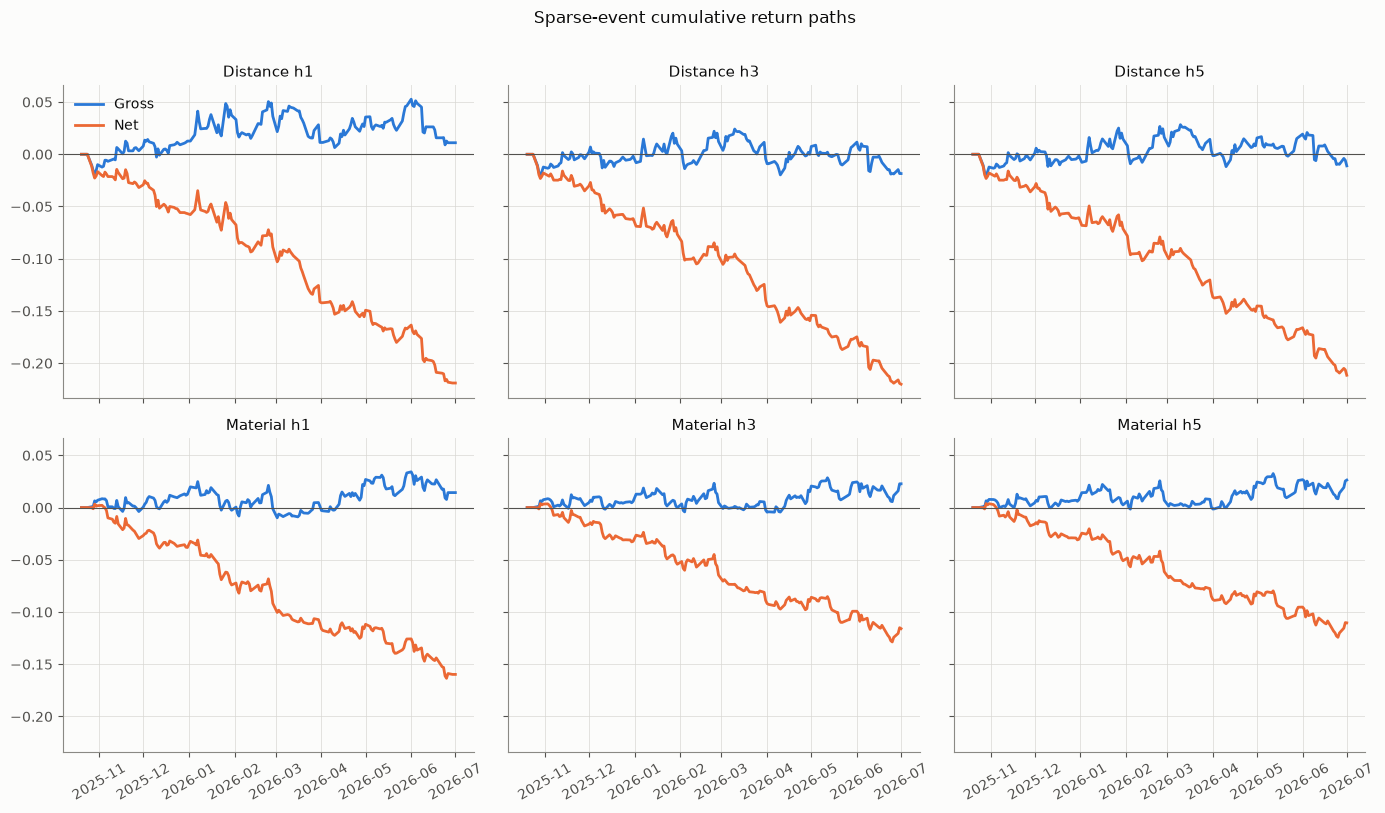

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
for ax, row in zip(axes.flat, plot_results.itertuples(index=False), strict=True):
    daily = daily_outputs[(row.signal, row.state_horizon_sessions)].copy()
    gross_curve = (1.0 + daily["gross_return"]).cumprod() - 1.0
    net_curve = (1.0 + daily["net_return"]).cumprod() - 1.0
    ax.plot(daily["session_date"], gross_curve, color=CATEGORICAL[0], label="Gross")
    ax.plot(daily["session_date"], net_curve, color=CATEGORICAL[1], label="Net")
    ax.axhline(0, color=INK["reference"], linewidth=0.8)
    ax.set_title(
        f"{'Material' if row.signal == 'material_signal' else 'Distance'} h{row.state_horizon_sessions}"
    )
    ax.tick_params(axis="x", rotation=30)
axes[0, 0].legend()
fig.suptitle("Sparse-event cumulative return paths", y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT / "six_arm_equity_curves.png", dpi=160, bbox_inches="tight")
plt.show()

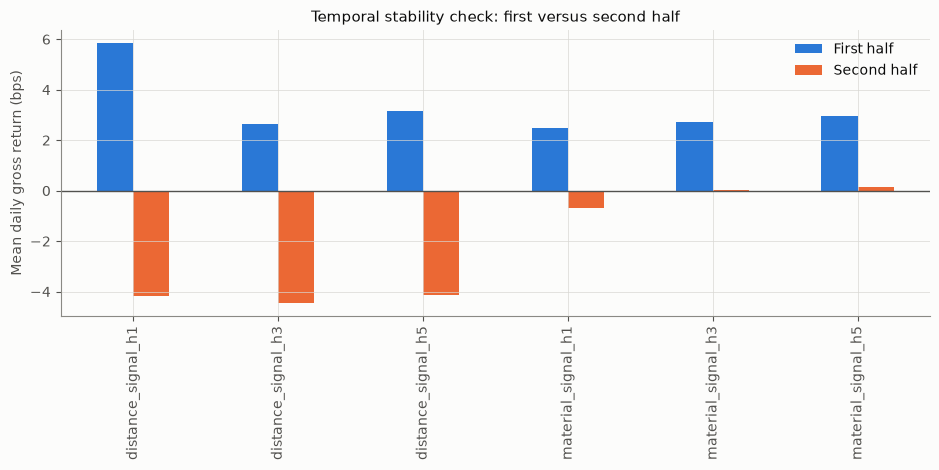

In [10]:
half_plot = plot_results[
    ["arm", "first_half_mean_gross", "second_half_mean_gross"]
].set_index("arm") * 10_000
fig, ax = plt.subplots(figsize=(9.5, 4.8))
half_plot.plot(kind="bar", ax=ax, color=[CATEGORICAL[0], CATEGORICAL[1]])
ax.axhline(0, color=INK["reference"], linewidth=1, label="_nolegend_")
ax.set_ylabel("Mean daily gross return (bps)")
ax.set_xlabel("")
ax.set_title("Temporal stability check: first versus second half")
ax.legend(["First half", "Second half"])
fig.tight_layout()
fig.savefig(OUTPUT / "temporal_stability.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Historical reference and verdict

The reference is the best-gross arm already disclosed in Notebook 13 after
that return window had been opened. It is shown for magnitude only. The new
six-arm family must stand on its own multiplicity and viability gates.

In [11]:
reference_all = pd.read_csv(REFERENCE_RESULTS)
reference = reference_all.loc[
    reference_all["scorer"].eq("gemma4_26b")
    & reference_all["aggregator"].eq("strongest_event")
].copy()
if len(reference) != 1:
    raise ValueError("Notebook 13 Gemma strongest-event reference is not unique")

reference_table = pd.DataFrame(
    [
        {
            "arm": "Notebook 13 Gemma strongest_event h1 reference",
            "ic": float(reference.iloc[0]["ic"]),
            "ic_p": float(reference.iloc[0]["ic_p"]),
            "sharpe_gross": float(reference.iloc[0]["sharpe_gross"]),
            "sharpe_net": float(reference.iloc[0]["sharpe_net"]),
            "breakeven_bps_per_side": float(
                reference.iloc[0]["breakeven_bps_per_side"]
            ),
            "bootstrap_net_ci_low": float(reference.iloc[0]["bootstrap_net_ci_low"]),
            "bootstrap_net_ci_high": float(reference.iloc[0]["bootstrap_net_ci_high"]),
            "family_role": "historical magnitude reference; outside new six-arm family",
        }
    ]
)
reference_table.to_csv(OUTPUT / "notebook13_reference.csv", index=False)
display(reference_table.style.format(precision=4))

best_gross = results.sort_values("sharpe_gross", ascending=False).iloc[0]
best_ic = results.sort_values("ic_p").iloc[0]
survivors = int(results["bh_reject_ic_q05"].sum())
viable = int(results["economically_viable"].sum())

if viable:
    verdict = (
        "FEASIBILITY SIGNAL ONLY: at least one retrospective arm clears every frozen "
        "gate, but promotion requires a new untouched time window and human validation."
    )
elif survivors:
    verdict = (
        "STATISTICAL BUT NOT ECONOMIC: at least one IC survives BH, but no arm clears "
        "the full cost, uncertainty, and temporal-stability gate."
    )
else:
    verdict = (
        "FALSIFIED ON THIS SNAPSHOT: no new IC survives BH and no arm clears the full "
        "economic gate. Preserve the null; do not tune this window again."
    )

comparison = pd.DataFrame(
    [
        {
            "item": "six-arm BH survivors",
            "value": survivors,
        },
        {
            "item": "six-arm economically viable arms",
            "value": viable,
        },
        {
            "item": "best new gross-Sharpe arm",
            "value": best_gross["arm"],
        },
        {
            "item": "best new gross Sharpe",
            "value": float(best_gross["sharpe_gross"]),
        },
        {
            "item": "best new break-even bps/side",
            "value": float(results["breakeven_bps_per_side"].max()),
        },
        {
            "item": "smallest new raw IC p arm",
            "value": best_ic["arm"],
        },
        {
            "item": "verdict",
            "value": verdict,
        },
    ]
)
comparison.to_csv(OUTPUT / "verdict.csv", index=False)
display(comparison)
print(verdict)

,arm,ic,ic_p,sharpe_gross,sharpe_net,breakeven_bps_per_side,bootstrap_net_ci_low,bootstrap_net_ci_high,family_role
0,Notebook 13 Gemma strongest_event h1 reference,0.0346,0.0992,1.2503,-2.1194,3.7087,-0.0019,0.0002,historical magnitude reference; outside new six-arm family


,item,value
0,six-arm BH survivors,0
1,six-arm economically viable arms,0
2,best new gross-Sharpe arm,material_signal_h5
3,best new gross Sharpe,0.662664
4,best new break-even bps/side,1.903812
5,smallest new raw IC p arm,material_signal_h5
6,verdict,FALSIFIED ON THIS SNAPSHOT: no new IC survives...


FALSIFIED ON THIS SNAPSHOT: no new IC survives BH and no arm clears the full economic gate. Preserve the null; do not tune this window again.


In [12]:
manifest = {
    "status": "completed",
    "analysis_status": "retrospective_discovery_falsification_not_holdout",
    "input": {
        "gemma_score_path": str(GEMMA_SCORES.relative_to(REPO_ROOT)),
        "gemma_score_sha256": score_audit["output_sha256"],
        "unique_successes": score_audit["unique_successes"],
        "price_paths": [
            str(SECTOR33_PRICES.relative_to(REPO_ROOT)),
            str(ADD11_PRICES.relative_to(REPO_ROOT)),
        ],
    },
    "design": {
        "signals": ["material_signal", "distance_signal"],
        "state_horizons_sessions": list(HOLDING_HORIZONS),
        "material_event_types": list(MATERIAL_EVENT_TYPES),
        "novelty_window_days": NOVELTY_WINDOW_DAYS,
        "novelty_jaccard_threshold": NOVELTY_JACCARD_THRESHOLD,
        "information_buffer_minutes": INFORMATION_BUFFER_MINUTES,
        "minimum_active_names": MIN_PORTFOLIO_NAMES,
        "cost_bps_per_side": COST_BPS_PER_SIDE,
        "multiplicity_family": SPARSE_PRIMARY_FAMILY,
        "bootstrap": {
            "block_length_sessions": BOOTSTRAP_BLOCK_SESSIONS,
            "replications": BOOTSTRAP_REPLICATIONS,
            "seed": SEED,
        },
    },
    "coverage": {
        "mapped_novel_headlines": int(mapped["headline_sha256"].nunique()),
        "selected_company_entry_events": int(len(selected)),
        "selected_with_distance_proxy": int(selected["distance_signal"].notna().sum()),
    },
    "result": {
        "bh_survivors": survivors,
        "economically_viable_arms": viable,
        "best_gross_sharpe_arm": str(best_gross["arm"]),
        "best_gross_sharpe": float(best_gross["sharpe_gross"]),
        "best_breakeven_bps_per_side": float(
            results["breakeven_bps_per_side"].max()
        ),
        "verdict": verdict,
    },
    "limitations": [
        "return window was already opened and influenced this design",
        "event taxonomy, novelty rule, and cash-flow-distance proxy are not human validated",
        "eight-month LSEG snapshot is separate from and not pooled with FNSPID",
        "raw open returns are split-adjusted but not dividend-back-adjusted",
        "passing would require replication on a new untouched time window",
    ],
    "licence_boundary": "no headline text written to notebook outputs",
}
(OUTPUT / "manifest.json").write_text(
    json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)
manifest

{'status': 'completed',
 'analysis_status': 'retrospective_discovery_falsification_not_holdout',
 'input': {'gemma_score_path': 'Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_26b_a4b_it_deepinfra_fp8_investor_headline_soft_label_v1.csv',
  'gemma_score_sha256': 'afb2d9c3029c4fba4fce3600218233a02d14051788f87313fd49c9da681c6d2f',
  'unique_successes': 888155,
  'price_paths': ['Data/derived/prices/lseg_us_sector_33_8m.csv',
   'Data/derived/prices/lseg_us_sector_add11_8m.csv']},
 'design': {'signals': ['material_signal', 'distance_signal'],
  'state_horizons_sessions': [1, 3, 5],
  'material_event_types': ['earnings_guidance',
   'mna_strategy',
   'legal_regulatory',
   'product_technology',
   'management_governance',
   'labor_esg'],
  'novelty_window_days': 30,
  'novelty_jaccard_threshold': 0.8,
  'information_buffer_minutes': 15,
  'minimum_active_names': 10,
  'cost_bps_per_side': 10.0,
  'multiplicity_family': 'two predeclared sparse signals x thr

## Interpretation contract

- A positive gross path without a BH-surviving IC is a noisy ranking, not
  evidence of alpha.
- A BH survivor that fails costs or bootstrap uncertainty is statistically
  interesting but not a viable trading strategy.
- Passing all gates would still be a feasibility signal only because this
  window is retrospective and the feature rules are not human validated.
- If the frozen family fails, the appropriate action is to preserve the null
  and stop tuning this return window—not to search more thresholds, event
  phrases, or holding periods.